
<center>

# Data Visualization 
## Part II
<center>
<img src="https://raw.githubusercontent.com/amandakube/Data118LectureImages/main/UChicago_DSI.png" alt="UC-DSI" width="300" height="100">
</center>
<br><br>

<img src="https://raw.githubusercontent.com/amandakube/Data118LectureImages/main/DSSI.png" width="800">
</center>



So far, when making data visualizations, we have been using `matplotlib` or `seaborn` functions to make a single graph. In `matplotlib` a *figure* is an object that acts as a container for all plot elements. *Axes* are objects that act as the bounds of plot elements. When creating graphs using `matplotlib` or `seaborn`, a figure with 1x1 axes is automatically created. We can change the number of axes made by using the `plt.subplots()` function. This function is useful for visualizing multiple plots side-by-side or automating the export of multiple plots. We can also view multiple datasets overlayed in one plot. We will see these options as we visualize several datasets in this lecture.

Per usual, import the necessary libraries:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
plt.style.use('seaborn-darkgrid')

Before making any graphs, it will helpful to know how to make a custom color palette. As previously mentioned, `matplotlib` offers a number of different default color maps, but sometimes, you may need to use specific colors for your visualizations. This can be done by creating a list of colors (either `matplotlib` named colors or hexadecimal codes) and using that list as input for `sns.set_palette()`:

In [ ]:
colors = ["#82a73f", '#5faebf']
pal = sns.set_palette(colors)

We will use this color palette later in one of our visualizations.

## Plotting multiple datasets using line graphs

Overlaying multiple line graphs is an easy way to view how trends in multiple datasets relate to one another. We will examine trends in minimum wages using data from the U.S. Department of Labor:

In [ ]:
wages = pd.read_csv('../Sample-Data/Minimum_Wage_Data.csv')
wages.head()

,Year,State,State.Minimum.Wage,State.Minimum.Wage.2020.Dollars,Federal.Minimum.Wage,Federal.Minimum.Wage.2020.Dollars,Effective.Minimum.Wage,Effective.Minimum.Wage.2020.Dollars,CPI.Average
0,1968,Alabama,0.00000,0.00,1.15,8.55,1.15,8.55,34.8
1,1968,Alaska,2.10000,15.61,1.15,8.55,2.10,15.61,34.8
2,1968,Arizona,0.46800,3.48,1.15,8.55,1.15,8.55,34.8
3,1968,Arkansas,0.15625,1.16,1.15,8.55,1.15,8.55,34.8
4,1968,California,1.65000,12.26,1.15,8.55,1.65,12.26,34.8


The `wages` dataset includes the minimum wage for each state since 1968 to 2020, as well as the federal minimum wage during this time period. Let's examine the growth patterns of the minimum wage rate for 3 states over this time period: Georgia, Connecticut, and Oregon. First, let's make separate dataframes for data pertaining to each state:

In [ ]:
GA = wages.loc[(wages['State'] == 'Georgia')]
CT = wages.loc[(wages['State'] == 'Connecticut')]
OR = wages.loc[(wages['State'] == 'Oregon')]

To readily plot this as a line graph, we can construct our dataframes such that the x-variable (i.e., the year) is set as the index and the y-variable (i.e. the state minimum wage) is the only column in the dataframe. In this way, the dataframe can be passed as is into `plt.plot()`

In [ ]:
GA.set_index('Year', inplace=True)
GA_2020 = GA[['State.Minimum.Wage']]

CT.set_index('Year', inplace=True)
CT_2020 = CT[['State.Minimum.Wage']]

OR.set_index('Year', inplace=True)
OR_2020 = OR[['State.Minimum.Wage']]

As always, we add the proper annotation to the graph:

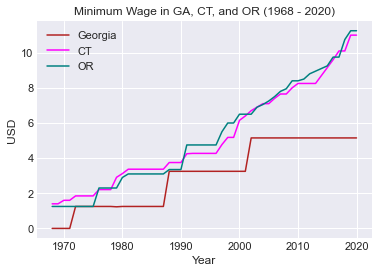

In [ ]:
plt.plot(GA_2020, color = 'firebrick')
plt.plot(CT_2020, color = 'magenta')
plt.plot(OR_2020, color = 'teal')
plt.legend(['Georgia', 'CT', 'OR'])
plt.title('Minimum Wage in GA, CT, and OR (1968 - 2020)')
plt.ylabel('USD')
plt.xlabel('Year')
plt.show()

Here, we can see the trends of three different datasets all on one plot. With a bit of alteration, we can also plot these same three datasets as separate graphs.

To do this, we first define our figure and our axes. We will define our figure as `fig` and define 3 axes (`ax1`, `ax2`, and `ax3`) in a tuple. These variables will be assigned to an object created by `plt.subplots()` that includes 1 row of 3 axes.

Then, on each axis, we can plot the data. Each axis can have it's own scale to fit the data:

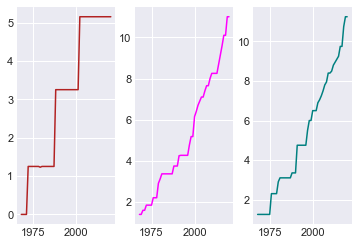

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)

ax1.plot(GA_2020, color = 'firebrick')

ax2.plot(CT_2020, color = 'magenta')

ax3.plot(OR_2020, color = 'teal')

plt.show()

This plot is alright, but it can be better. We can improve it by increasing the width and allowing for more space to see the granularity of the x-axis. This is achieve through the `figsize` parameter of `plt.subplots()`. Furthermore, we can share the y-axis across all three plots so that the y-axis scale is maintained only on the left-most graph by using the `sharey` parameter.


We can also set a title and y-axis limits for each graph to make comparison easy and consistent across graphs. This is accomplished using `.set_title()` and `.set_ylim()` methods on each individual axis. The y-axis limits can be specified on `ax1`, as it is the left-most plot of the subplot. The x-axis labels can be specified on `ax2`, as it is the center plot.

Lastly, the title for the entire plot can be set using `fig.suptitle()`

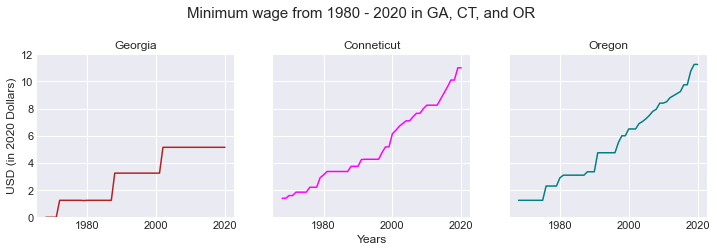

In [ ]:
(fig, (ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(12, 3),  sharey= True)

ax1.plot(GA_2020, color = 'firebrick')
ax1.set_title('Georgia')
ax1.set_ylim([0, 12])
ax1.set_ylabel('USD (in 2020 Dollars)')

ax2.plot(CT_2020, color='magenta')
ax2.set_title('Conneticut')
ax2.set_ylim([0, 12])
ax2.set_xlabel('Years')

ax3.plot(OR_2020, color='teal')
ax3.set_title('Oregon')
ax3.set_ylim([0, 12])

fig.suptitle('Minimum wage from 1980 - 2020 in GA, CT, and OR', y=1.1, fontsize=15)

plt.show()

## Plotting multiple datasets on a bar graph

Plotting multiple datasets using a bar graph makes for easy comparison across different categories. We will use a preloaded dataset to practice making a nested bar graph. Let's load the `tips` dataset using `sns.load_dataset()`

In [ ]:
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


The `tips` dataset have several variables that are measured. Let's examine the average amount of tips given to male and female servers during lunch and dinner. We will need to group our data:

In [ ]:
tips_sub = tips.groupby(['time','sex'])[['tip']].mean()
tips_sub.reset_index(inplace=True)
tips_sub

,time,sex,tip
0,Lunch,Male,2.882121
1,Lunch,Female,2.582857
2,Dinner,Male,3.144839
3,Dinner,Female,3.002115


Using `sns.barplot()` function, we can plot the average tip amount across dining times between the sexes. Here, we color our bars based on the sex by setting `hue=True`. Because we are creating a graph that compares groups side-by-side, we set `dodge=True`. We can use our color palette `pal` that we made earlier as an argument for `palette`.

As before, the location of our legend is dictated by the coordinates used for the `bbox_to_anchor`, which indicate the location within the figure:

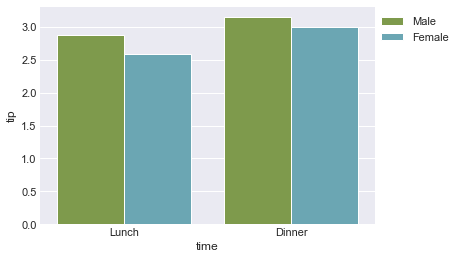

In [ ]:
sns.barplot(x="time", y="tip", hue="sex", data=tips_sub, dodge=True,  palette=pal)

plt.legend(bbox_to_anchor = (1.25,1))

plt.show()

## Plotting multiple datasets using histograms

Being able to see multiple distributions in one setting is a frequent need in data science. Using the `iris` dataset, we will learn how to overlay histograms and plot them separately within the same figure.

First, we load the data:

In [ ]:
iris = sns.load_dataset('iris')

iris.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


Remembering that histograms are used to visualize counts and frequencies of numeric data, we can see that there are several columns whose distributions we can visualize. Let's examine the minimum and maximum values in petal length, sepal length, and sepal width in this dataset:

In [ ]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The `.describe()` method reveals that all values of petal length, sepal length, and sepal width are between 1 and 8. With this, we can make bins that could be used acrossed all three datasets.

With these bins, we can create a single plot that has all three distributions overlaying. Calling `plt.hist()` for each dataset creates separate plotting elements that can be customized individually. The `alpha` parameter controlls the opacity of each distribution, setting this value to less than 1 allows for all the overlayed elements to be seen.

In this example, the location of our legend was set using `loc` instead of `bbox_to_anchor` this works because there is a spot in the graph where the histograms from our datasets don't clash with the legend, and thus setting `loc='upper right'` works for this visualization. In times where the data takes up the entire plotting area, `bbox_to_anchor` serves as a great way to place the legend outside of the plotting area.

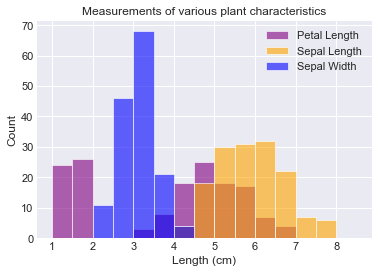

In [ ]:
binz = np.arange(1,9, step = 0.5)

# plotting histograms
plt.hist(data['petal_length'], label='Petal Length', alpha=0.6, color = 'purple', bins=binz)

plt.hist(data['sepal_length'], label='Sepal Length', alpha=0.6, color = 'orange', bins=binz)

plt.hist(data['sepal_width'], label='Sepal Width', alpha=0.6, color = 'blue', bins=binz)

plt.legend(loc='upper right')
plt.title('Measurements of various plant characteristics')
plt.xlabel('Length (cm)')
plt.ylabel('Count')
plt.show()


Alternatively, we can view these distributions on separate subplots. By creating our figure and axes again, we can plot to each axis using the `.hist()` method. Similar to before, each subplot can get it's own title and axis labels. If we don't set `binz` as our bins for each plot, the bins will be automatically generated based on the distribution of the data. This results in the x-axis of each plot having different increments:

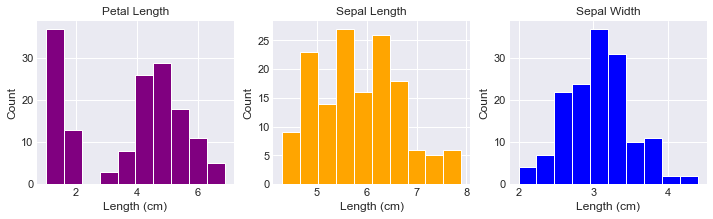

In [ ]:
(fig, (ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(12, 3))

ax1.hist(data['petal_length'], color = 'purple')
ax1.set_title('Petal Length')
ax1.set_xlabel('Length (cm)')
ax1.set_ylabel('Count')

ax2.hist(data['sepal_length'], color = 'orange')
ax2.set_title('Sepal Length')
ax2.set_xlabel('Length (cm)')
ax2.set_ylabel('Count')

ax3.hist(data['sepal_width'], color = 'blue')
ax3.set_title('Sepal Width')
ax3.set_xlabel('Length (cm)')
ax3.set_ylabel('Count')

plt.show()

<code style="background:yellow;color:black">notes:</code>
- Make PPT lecture about colorblind friendly colors, matplotlib colors, hexadecimal color wheel, always label your graphs

Activity?